In [1]:
module chebyshev_method

    using LinearAlgebra

    export chebyshev_D
    # Chebyshev compute D = differentiation matrix, x = Chebyshev grid

    function  chebyshev_D(N)

        if N==0
            D = 0;
            x = 1;
            return D, x
        else
            θ = range(0, pi, N+1)
            x = reshape(-cos.(θ), N+1, 1)
            c = [2; ones(N-1, 1) ; 2] .* (-1) .^ (0:N)
            X = repeat(x, 1, N+1);
            dX = X - X';
            D = (c * (1 ./ c)') ./ (dX .+ I(N+1));   # off-diagonal entries
            D = D - diagm(vec(sum(D, dims=2)));      # diagonal entries
            return D, x
        end
    end
end

Main.chebyshev_method

In [2]:
import .chebyshev_method as cheby
using LinearAlgebra
using Plots

In [36]:
N = 98
D,x = cheby.chebyshev_D(N+1)
U = 1 .- x.^2
dU = -2 .* x
ddU = -2 *ones(N+2,1)
dU1 = D * U
U1 = (D^2)\ddU

100×1 Matrix{Float64}:
 -0.009490678522008576
 -0.008479579249362863
 -0.005450339371250083
 -0.0004151163807424718
  0.006605881589306509
  0.015584477069887291
  0.02648463662229558
  0.039262615811046626
  0.05386713519960234
  0.07023958666039178
  ⋮
  0.07093026238960179
  0.056457620561328276
  0.04379420502063424
  0.03299117984817482
  0.024092191673348494
  0.017133193777050405
  0.012142301199471602
  0.009139677436496811
  0.00813745318102717

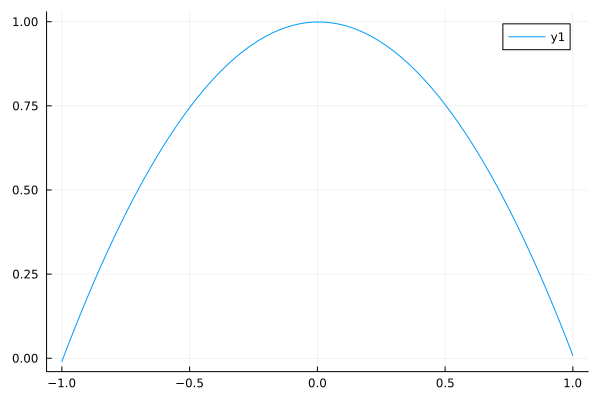

In [37]:
plot(x,U1)